# MLPs for Function Regression

| Date | Who | Mail |  What |
| ---  | --- | ---  | ---   |     
| Nov 24, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Initial code created using Gemini 3.0 |
| Nov 24, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Improvements to code and comments |

Here, we will explore one of the most fundamental capabilities of neural networks: **function approximation**.

In theory, the **Universal Approximation Theorem** states that a feedforward network with a single hidden layer and sufficient neurons can approximate any continuous function. Today, we will prove this to ourselves empirically. We will build a Multilayer Perceptron (MLP) in PyTorch to "learn" the shape of a function.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from numpy import sqrt



## 1. Data generation and normalization

### 1.1 Data generation
First, we must create our "ground truth." We will generate a synthetic dataset based on a damped sine wave:
$$
y = e^{-0.1x} \cdot \sin(x)
$$
and we will add some Gaussian noise to simulate real-world data imperfections.

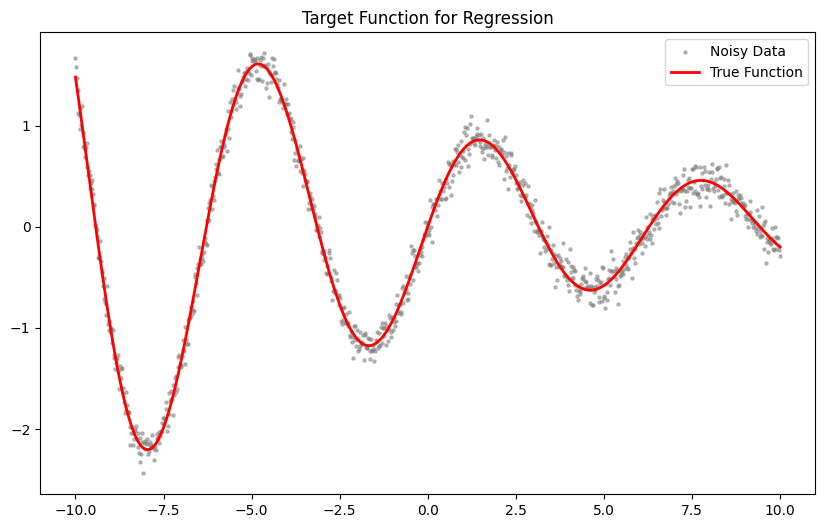

In [ ]:
# Set seeds for reproducibility
torch.manual_seed(42)

# Configuration
N_SAMPLES = 1000

# 1. Generate Data: y = y = exp(-0.1*x)*sin(x) + noise
# We create a range of X values from -10 to 10
X = torch.linspace(-10, 10, N_SAMPLES).reshape(1, -1) # size 1xN_SAMPLES
noise = torch.normal(mean=0, std=0.1, size=X.shape)
y_true = torch.exp(-0.1 * X) * torch.sin(X)
y = y_true + noise

# Visualization of our dataset
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=5, alpha=0.5, label='Noisy Data', color='gray')
plt.plot(X.squeeze(), y_true.squeeze(), color='red', linewidth=2, label='True Function')
plt.title("Target Function for Regression")
plt.legend()
plt.show()

### 1.2 Data splitting

Here is the professional standard for data handling:

1.  **Training Set (\~70%):** Used to calculate gradients and update weights.
2.  **Validation Set (\~15%):** Used to monitor performance *during* training (to tune hyperparameters or stop early). The model **never** sees these gradients.
3.  **Test Set (\~15%):** The "Final Exam." Used only once at the very end to estimate real-world performance.



In [ ]:
VAL_PCT  = 0.15
TEST_PCT = 0.70

# Shuffle indices
indices = torch.randperm(N_SAMPLES)
test_size = int(N_SAMPLES * TEST_PCT)
val_size  = int(N_SAMPLES * VAL_PCT)

test_idx  = indices[:test_size]
val_idx   = indices[test_size:test_size + val_size]
train_idx = indices[test_size + val_size:]

X_train, y_train = X[:,train_idx], y[:,train_idx]
X_val,   y_val   = X[:,  val_idx], y[:,  val_idx]
X_test,  y_test  = X[:, test_idx], y[:, test_idx]

print(f"Train size: {X_train.shape}, Val size: {val_size}, Test size: {test_size}")

Train size: torch.Size([1, 150]), Val size: 150, Test size: 700



### 1.3 Data normalization

Neural networks struggle when input features have vastly different ranges or are far from zero. Normalizing (specifically "Standardization") shifts inputs to have a mean of 0 and a standard deviation of 1. This ensures the error surface is more spherical, allowing the gradient descent algorithm to converge much faster and with a higher learning rate.

The formula for standardization is:
$$x' = \frac{x - \mu}{\sigma}$$

**Note:** We calculate $\mu$ (mean) and $\sigma$ (std) *only* on the training set, then apply those stats to validation and test sets. If we use the whole dataset, information from the test set "leaks" into the training process, cheating the results.

In [ ]:
mu  = X_train.mean()
std = X_train.std()

X_train_norm = (X_train - mu)/std
X_val_norm   = (X_val   - mu)/std
X_test_norm  = (X_test  - mu)/std

-----

## 2\. The "By Hand" Approach: Understanding Autograd

Before using high-level layers, we must understand what happens under the hood. We will define weights and biases as raw tensors and manually update them using gradient descent.

We will implement a simple architecture: **Input $\to$ Hidden Layer$\to$ Output**.

$$h = \phi(X W_1 + b_1)$$
$$\hat{y} = h W_2 + b_2$$

In [ ]:
HIDDEN_NEURONS = 10
activation = torch.nn.Tanh()  # OJO CAMBIAR POR RELU, Y OTRAS FUNC DE ACTIVACION

# Kaiming's initialization of weights
W1 = torch.normal(mean=0, std=sqrt(2/1), size=(HIDDEN_NEURONS, 1))
b1 = torch.zeros(HIDDEN_NEURONS, 1)

W2 = torch.normal(mean=0, std=sqrt(2/HIDDEN_NEURONS), size=(1, HIDDEN_NEURONS))
b2 = torch.zeros(1, 1)

# Tell PyTorch we need gradients for these
params = [W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

and then, we will manually perform the Gradient Descent update step using the gradients computed by PyTorch's Autograd engine:
$$\theta_{new} = \theta_{old} - \alpha \cdot \nabla J(\theta)$$
here $\alpha$ is the learning rate and $\nabla J(\theta)$ is the gradient.

By manually updating `p -= lr * p.grad`, you replicated exactly what `optim.SGD` does behind the scenes.

In [ ]:
EPOCHS = 20000
LR     = 0.1  # learning rate
history = {'train_loss': [], 'val_loss': []}

# Loss Function: Mean Squared Error
def loss_fn(y_pred, y_target):
    return torch.mean((y_pred - y_target)**2)

def forward_pass(X):
    # A helper function to avoid code repetition
    z1 = W1@X + b1
    a1 = activation(z1)
    y_pred = W2@a1 + b2
    return y_pred

print("Starting manual training...")
for epoch in range(EPOCHS):
    # 1. Forward Pass
    y_pred = forward_pass(X_train_norm)

    # 2. Compute Loss (MSE)
    loss = loss_fn(y_pred, y_train)

    # 3. Backward Pass
    # PyTorch computes dLoss/dWeights for all weights
    loss.backward()

    # 4. Optimizer Step
    with torch.no_grad():
        sqr_grad_norm = 0
        for p in params:
            sqr_grad_norm += p.grad.norm().item()**2
            p -= LR * p.grad # The Descent Step
            p.grad.zero_()   # Reset gradients for the next loop!

        # --- VALIDATION STEP ---
        # Check how well we perform on unseen data
        val_pred = forward_pass(X_val_norm)
        val_loss = loss_fn(val_pred, y_val)

    history['train_loss'].append(loss.item())
    history['val_loss'].append(val_loss.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.4f} | Grad Norm: {sqrt(sqr_grad_norm):.4f}")

Starting manual training...
Epoch     0 | Loss: 0.9412 | Grad Norm: 2.0661
Epoch  1000 | Loss: 0.5357 | Grad Norm: 0.0297
Epoch  2000 | Loss: 0.4543 | Grad Norm: 0.0331
Epoch  3000 | Loss: 0.3432 | Grad Norm: 0.0256
Epoch  4000 | Loss: 0.2944 | Grad Norm: 0.0429
Epoch  5000 | Loss: 0.0707 | Grad Norm: 0.4660
Epoch  6000 | Loss: 0.0492 | Grad Norm: 0.9063
Epoch  7000 | Loss: 0.0292 | Grad Norm: 0.4934
Epoch  8000 | Loss: 0.0227 | Grad Norm: 0.2587
Epoch  9000 | Loss: 0.0203 | Grad Norm: 0.1330
Epoch 10000 | Loss: 0.0191 | Grad Norm: 0.0629
Epoch 11000 | Loss: 0.0184 | Grad Norm: 0.0216
Epoch 12000 | Loss: 0.0179 | Grad Norm: 0.0041
Epoch 13000 | Loss: 0.0171 | Grad Norm: 0.0033
Epoch 14000 | Loss: 0.0152 | Grad Norm: 0.0056
Epoch 15000 | Loss: 0.0124 | Grad Norm: 0.0039
Epoch 16000 | Loss: 0.0157 | Grad Norm: 0.4039
Epoch 17000 | Loss: 0.0134 | Grad Norm: 0.3102
Epoch 18000 | Loss: 0.0125 | Grad Norm: 0.2748
Epoch 19000 | Loss: 0.0118 | Grad Norm: 0.2512


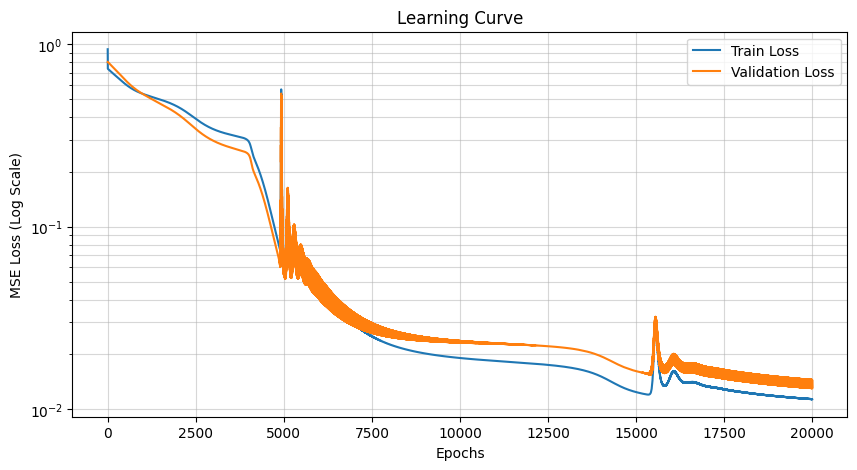

In [ ]:
# Plot Learning Curves (Log Scale)
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (Log Scale)')
plt.title('Learning Curve')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()


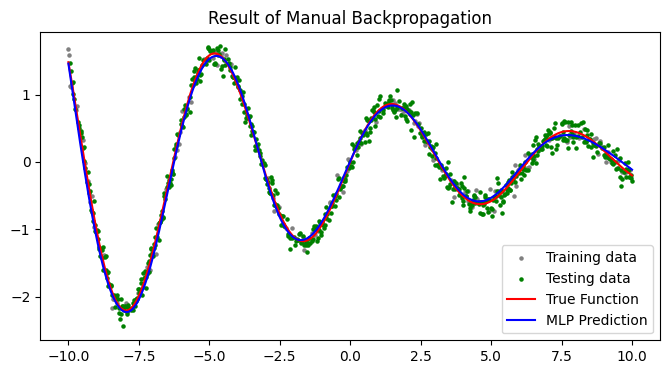


Test error with MSE: 0.01307


In [ ]:
# Plot final fit
with torch.no_grad():
    # Re-run forward pass for plotting
    MLP_pred = forward_pass((X - mu)/std)

plt.figure(figsize=(8,4))
plt.scatter(X_train,     y_train,            color='gray',  label='Training data', s=5)
plt.scatter(X_test,      y_test,             color='green', label='Testing data',  s=5)
plt.plot   (X.squeeze(), y_true.squeeze(),   color='red',   label='True Function')
plt.plot   (X.squeeze(), MLP_pred.squeeze(), color='blue',  label='MLP Prediction')
plt.title("Result of Manual Backpropagation")
plt.legend()
plt.show()

# Test error calculation
with torch.no_grad():
    test_pred = forward_pass(X_test_norm)
    test_loss = loss_fn(test_pred, y_test)

print(f"\nTest error with MSE: {test_loss.item():.5f}")

### 3. Designing the Architecture

Now, we implement the same logic using `torch.nn` (this is the professional standard in PyTorch). This abstracts away weight initialization and matrix multiplication details. We will also use the **Adam** optimizer, which adapts the learning rate for each parameter, generally converging faster than standard Stochastic Gradient Descent.

In [ ]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLPRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            # Linear activation on output for regression
            nn.Linear(hidden_dim, output_dim)
        )

        # Apply Kaiming initialization to linear layers
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Expects input x of shape (1, N) from previous steps,
        # but nn.Linear expects (N, 1), so transpose here.
        return self.net(x.T)

### 4. Loss and Optimizer

For regression (predicting a continuous number), we almost always use **Mean Squared Error (MSE)**.

In [ ]:
# Loss Function: Mean Squared Error
loss_fn = nn.MSELoss()

### 4\. The Training Loop

This is the engine of PyTorch. We iterate through our data, predict, calculate error, and update weights.

In [ ]:
model = MLPRegressor(input_dim=1, hidden_dim=20, output_dim=1)
print(model)

optimizer = optim.Adam(model.parameters(), lr=0.01)
print(optimizer)


MLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): ReLU()
    (6): Linear(in_features=20, out_features=1, bias=True)
  )
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


Epoch     0 | Loss: 1.3198 | Grad Norm: 9.5688
Epoch  1000 | Loss: 0.0105 | Grad Norm: 0.7350
Epoch  2000 | Loss: 0.0077 | Grad Norm: 0.1784
Epoch  3000 | Loss: 0.0073 | Grad Norm: 0.3698
Epoch  4000 | Loss: 0.0071 | Grad Norm: 0.4005
Epoch  5000 | Loss: 0.0076 | Grad Norm: 0.6417
Epoch  6000 | Loss: 0.0073 | Grad Norm: 0.5081
Epoch  7000 | Loss: 0.0066 | Grad Norm: 0.1014
Epoch  8000 | Loss: 0.0075 | Grad Norm: 0.6605
Epoch  9000 | Loss: 0.0071 | Grad Norm: 0.3708
Epoch 10000 | Loss: 0.0075 | Grad Norm: 0.5176
Epoch 11000 | Loss: 0.0069 | Grad Norm: 0.3627
Epoch 12000 | Loss: 0.0077 | Grad Norm: 0.6090
Epoch 13000 | Loss: 0.0084 | Grad Norm: 0.8130
Epoch 14000 | Loss: 0.0065 | Grad Norm: 0.2482
Epoch 15000 | Loss: 0.0073 | Grad Norm: 0.6184
Epoch 16000 | Loss: 0.0065 | Grad Norm: 0.3202
Epoch 17000 | Loss: 0.0067 | Grad Norm: 0.3642
Epoch 18000 | Loss: 0.0064 | Grad Norm: 0.3204
Epoch 19000 | Loss: 0.0075 | Grad Norm: 0.6760


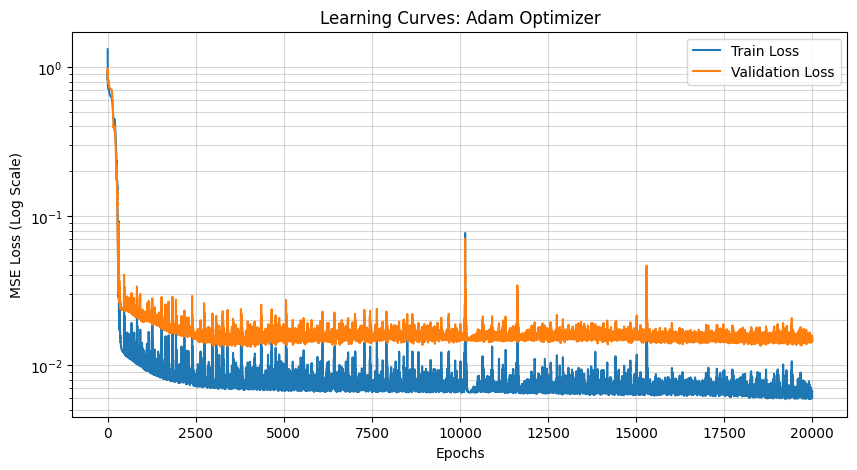

In [ ]:
history = {'train_loss': [], 'val_loss': []}

# Training loop
for epoch in range(EPOCHS):
    model.train() # Set to training mode

    # Forward pass
    y_pred = model(X_train_norm)

    # Calculate loss
    # Reshape y_train from (1, N) to (N, 1) to match y_pred
    loss = loss_fn(y_pred, y_train.T)

    # Backward pass (backpropagation)
    optimizer.zero_grad()   # Clear previous gradients
    loss.backward()         # Compute gradients

    # Calculate gradient norm BEFORE optimizer.step()
    sqr_grad_norm = 0
    for p in model.parameters():
        if p.grad is not None: # Ensure gradient exists
            sqr_grad_norm += p.grad.norm().item()**2

    optimizer.step()        # Update weights

    # Validation
    model.eval() # Set to evaluation mode
    with torch.no_grad():
        # Turn off gradient tracking for inference
        val_pred = model(X_val_norm)
        # Reshape y_val from (1, N) to (N, 1) to match val_pred
        val_loss = loss_fn(val_pred, y_val.T)

    history['train_loss'].append(loss.item())
    history['val_loss'  ].append(val_loss.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.4f} | Grad Norm: {sqrt(sqr_grad_norm):.4f}")

# Plot Learning Curves (Log Scale)
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (Log Scale)')
plt.title('Learning Curves: Adam Optimizer')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

### 5\. Evaluation & Visualization

We will plot the model's predictions (red line) on top of the noisy data (blue dots).

Notice the using ReLU activation functions, the red prediction line becomes "jagged" or angular. This demonstrates that ReLU constructs functions using piece-wise linear segments.

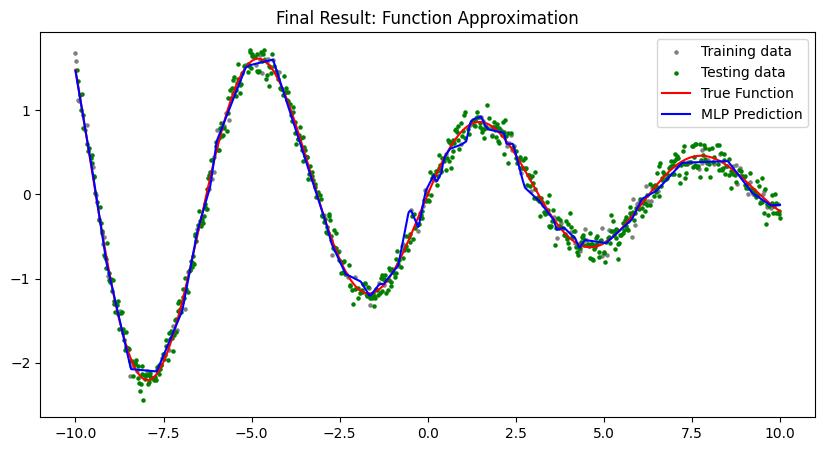

In [ ]:
# Plotting the Final Regression Fit
model.eval() # Set model to evaluation mode
with torch.no_grad(): # Turn off gradient tracking for inference
    MLP_pred = model((X - mu)/std)

plt.figure(figsize=(10, 5))
plt.scatter(X_train,     y_train,            color='gray',  label='Training data', s=5)
plt.scatter(X_test,      y_test,             color='green', label='Testing data',  s=5)
plt.plot   (X.squeeze(), y_true.squeeze(),   color='red',   label='True Function')
plt.plot   (X.squeeze(), MLP_pred.squeeze(), color='blue',  label='MLP Prediction')
plt.title("Final Result: Function Approximation")
plt.legend()
plt.show()

[Multilayer Perceptron Regression Tutorial on YouTube](https://www.youtube.com/watch?v=LqQsjQpX4xk)

-----

## 6. Model Capacity and Learning Dynamics

In this final section, we will visualize three critical concepts by varying the **width** (number of neurons) of our hidden layer.

1.  **Underfitting:** The model is too simple to capture the curve.
2.  **Overfitting:** The model memorizes noise in the training set.
3.  **Double Descent:** As model capacity increases, test error drops (classic regime), then rises (overfitting), and then **drops again** (interpolation regime) as the model becomes massively over-parameterized.

*Note: Double descent is complex to visualize perfectly on small data, but we will attempt to show the trend by training many models of increasing width.*

In [ ]:
class MLPRegressorTanh(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLPRegressorTanh, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            # Linear activation on output for regression
            nn.Linear(hidden_dim, output_dim)
        )

        # Apply Kaiming initialization to linear layers
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='tanh')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Expects input x of shape (1, N) from previous steps,
        # but nn.Linear expects (N, 1), so transpose here.
        return self.net(x.T)

In [ ]:
EPOCHS = 5000 # Reduced epochs for faster execution during this illustration
LR = 0.01

# Select a few representative widths for visualization
# These correspond to underfitting, good fit/overfitting, and double descent regions
widths = [1, 2, 3, 5, 6, 7, 8, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50, 75, 100]
predicted_functions = {}
final_train_losses = []
final_test_losses = []

for w in widths:
    print(f"\nTraining model with {w} hidden neurons...")
    model = MLPRegressorTanh(input_dim=1, hidden_dim=w, output_dim=1)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    for epoch in range(EPOCHS):
        model.train()
        y_pred = model(X_train_norm)
        loss = loss_fn(y_pred, y_train.T)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate on training and test sets after training
    model.eval()
    with torch.no_grad():
        train_pred = model(X_train_norm)
        train_loss = loss_fn(train_pred, y_train.T).item()

        test_pred = model(X_test_norm)
        test_loss = loss_fn(test_pred, y_test.T).item()

    final_train_losses.append(train_loss)
    final_test_losses.append(test_loss)

    # Store predictions for plotting
    with torch.no_grad():
        predicted_functions[w] = model((X - mu)/std).squeeze().numpy()
    print(f"  Final Train Loss: {train_loss:.5f}, Final Test Loss: {test_loss:.5f}")


Training model with 1 hidden neurons...
  Final Train Loss: 0.66940, Final Test Loss: 0.63150

Training model with 2 hidden neurons...
  Final Train Loss: 0.60453, Final Test Loss: 0.73614

Training model with 3 hidden neurons...
  Final Train Loss: 0.09134, Final Test Loss: 0.08737

Training model with 5 hidden neurons...
  Final Train Loss: 0.03260, Final Test Loss: 0.03399

Training model with 6 hidden neurons...
  Final Train Loss: 0.52737, Final Test Loss: 0.66055

Training model with 7 hidden neurons...
  Final Train Loss: 0.00969, Final Test Loss: 0.01081

Training model with 8 hidden neurons...
  Final Train Loss: 0.00946, Final Test Loss: 0.01112

Training model with 10 hidden neurons...
  Final Train Loss: 0.00938, Final Test Loss: 0.01101

Training model with 12 hidden neurons...
  Final Train Loss: 0.00926, Final Test Loss: 0.01081

Training model with 15 hidden neurons...
  Final Train Loss: 0.00922, Final Test Loss: 0.01096

Training model with 20 hidden neurons...
  Fin

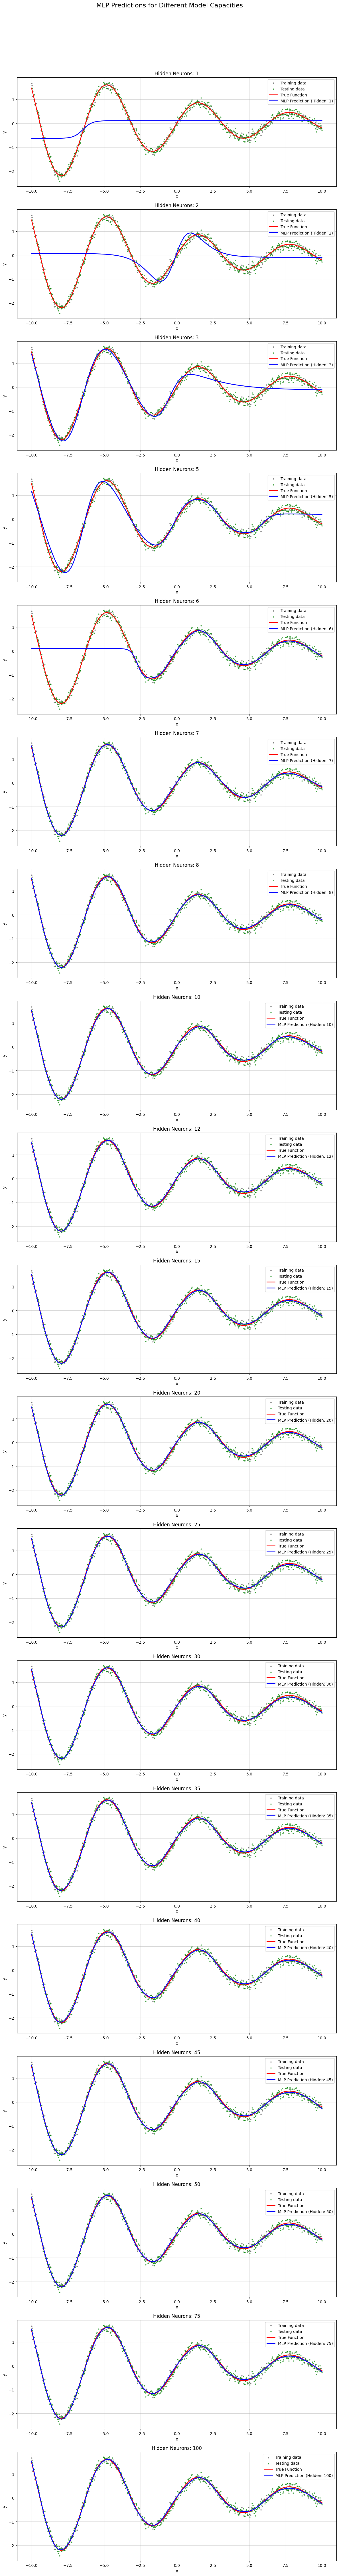

In [ ]:
fig, axes = plt.subplots(len(widths), 1, figsize=(12, 5 * len(widths)))
fig.suptitle('MLP Predictions for Different Model Capacities', fontsize=16)

for i, w in enumerate(widths):
    ax = axes[i]
    ax.scatter(X_train, y_train, color='gray', label='Training data', s=5)
    ax.scatter(X_test, y_test, color='green', label='Testing data', s=5, alpha=0.6)
    ax.plot(X.squeeze(), y_true.squeeze(), color='red', label='True Function', linewidth=2)
    ax.plot(X.squeeze(), predicted_functions[w], color='blue', label=f'MLP Prediction (Hidden: {w})', linewidth=2)
    ax.set_title(f'Hidden Neurons: {w}')
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()


### Interpretation of Results

1.  **Underfitting (Left Graph, Red Line):** With only 1 neuron, the model is essentially linear (ReLU acts linearly if inputs are all positive or zeroed out). It cannot curve to match the sine wave.
2.  **Overfitting (Right Graph, Orange Line):** Look at the width around 8-15. The training loss drops, but the test loss might spike. The model is complex enough to fit noise but not robust enough to generalize.
3.  **Double Descent (Right Graph):** As width increases beyond 50-100, you often see the test loss drop *again*. Even though the model is "too big" (more parameters than data points), the optimization dynamics of Stochastic Gradient Descent act as an implicit regularizer, smoothing out the function and leading to good generalization.

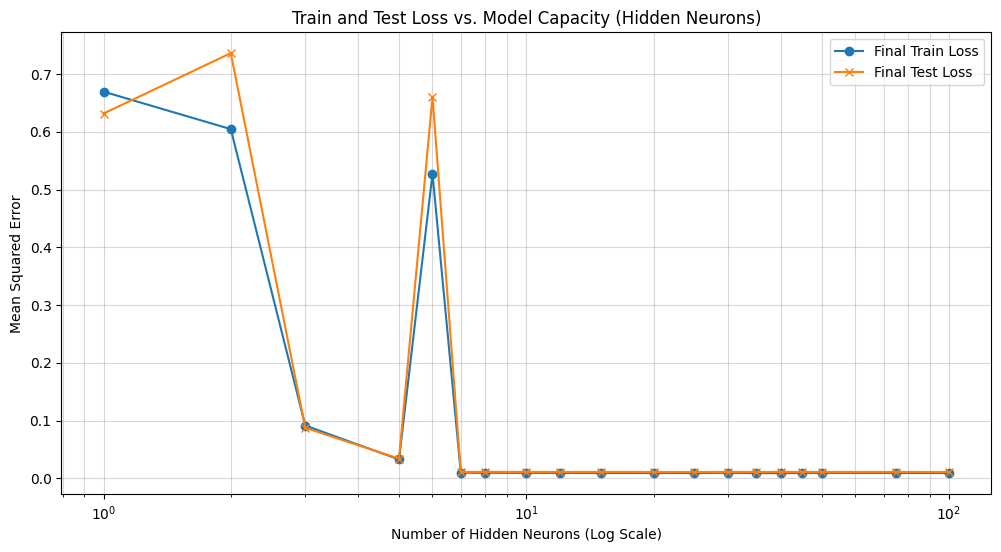

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(widths, final_train_losses, label='Final Train Loss', marker='o')
plt.plot(widths, final_test_losses, label='Final Test Loss', marker='x')
plt.xscale('log') # Use log scale for x-axis as widths vary greatly
plt.title('Train and Test Loss vs. Model Capacity (Hidden Neurons)')
plt.xlabel('Number of Hidden Neurons (Log Scale)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()
